### Loading Datasets

In [1]:
import numpy as np
import pandas as pd
pd.options.mode.chained_assignment = None

df = pd.read_csv("./datasets/honkai_impact_reviews.csv")
df.head()

C:\Users\User\AppData\Local\Temp\ipykernel_12408\2828200977.py:5: DtypeWarning: Columns (7,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./datasets/honkai_impact_reviews.csv")


,Unnamed: 0,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,0,e7689f7e-e93b-49c2-a25a-c3393e549446,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Game anime ini sudah bagus. Pertama main sih b...,5,11,8.0.0,2025-02-20 20:58:44,NaN,NaN,8.0.0
1,1,b9a94c49-c341-4dff-a307-53720a98e526,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Game yang bagus, terimakasih juga untuk perbai...",5,392,8.0.0,2025-01-23 11:58:42,NaN,NaN,8.0.0
2,2,0a6f35f1-0061-4028-81d0-44852fee00fe,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Story di game nya sangat menarik dan bisa memb...,4,6,8.0.0,2025-02-20 14:28:26,NaN,NaN,8.0.0
3,3,777de78b-e7f0-46d4-a5ff-e128da73c7a2,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Nah ini, yang aku sukak dari honkai impact, ya...",5,11,8.1.0,2025-02-20 20:07:05,NaN,NaN,8.1.0
4,4,031ba94b-2ce8-49ee-bb71-84e8ed21a127,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Hai Hoyovers sebenarnya ini game bagus, hanya ...",4,0,8.0.0,2025-02-18 19:42:34,NaN,NaN,8.0.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65851 entries, 0 to 65850
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Unnamed: 0            65851 non-null  int64 
 1   reviewId              65851 non-null  object
 2   userName              65851 non-null  object
 3   userImage             65851 non-null  object
 4   content               65851 non-null  object
 5   score                 65851 non-null  int64 
 6   thumbsUpCount         65851 non-null  int64 
 7   reviewCreatedVersion  39061 non-null  object
 8   at                    65851 non-null  object
 9   replyContent          14910 non-null  object
 10  repliedAt             14910 non-null  object
 11  appVersion            39061 non-null  object
dtypes: int64(3), object(9)
memory usage: 6.0+ MB


In [3]:
clean_df = df.drop(columns=[col for col in df.columns if col != "content"])

In [4]:
missing_info = pd.DataFrame({
    "missing_values":  clean_df.isnull().sum(),
    "percent_miss": clean_df.isnull().mean() * 100
})

missing_info

,missing_values,percent_miss
content,0,0.0


In [5]:
print(clean_df.duplicated().sum())
clean_df[clean_df.duplicated()]

12200


,content
766,Untuk developer miHoYo. saya mohon sekali tolo...
3414,good game.dari semua game rpg tipe anime game ...
7127,Download dari google play store maupun situs r...
9370,Sumpah kecewa banget sama ni game 😡 masa downl...
16020,Grafik nya bagus
...,...
65841,👍
65843,👎
65844,😑
65847,🤬


In [6]:
clean_df.drop_duplicates(subset="content", inplace=True)

In [7]:
clean_df.duplicated().sum()

0

In [8]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53651 entries, 0 to 65850
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  53651 non-null  object
dtypes: object(1)
memory usage: 838.3+ KB


### Pre-processing Text

In [9]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

def simple_cleaning(text: str)-> str:
    text = re.sub(r"#[A-Za-z0-1_]+", "", text)
    text = re.sub(r"@[A-Za-z0-1_]+", "", text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[0-9]+", "", text)
    text = re.sub(r"[^\w\s]", "", text)

    text = text.replace("\n", " ")
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    text = text.lower()

    return text

def fix_slang_words(text: str)-> str:
    slang_list = {
        "p2w": "bayar untuk menang",
        "pay to win": "bayar untuk menang",
        "rateup": "naik",
        "whale": "kaya",
        "gacha": "harap",
        "wish": "harap",
        "f2p": "gratis",
        "crystal": "uang",
        "asterite": "uang",
        "mithril": "uang",
        "coin": "uang",
        "banner": "event",
        "meta": "kuat",
        "dps": "damage",
        "support": "dukung",
        "abyss": "tantang",
        "sultan": "kaya",
        "luck": "untung",
        "cuan": "untung",
        "beban": "tidak berguna",
        "build": "rakit",
        "resinbocor": "buang",
        "nerf": "lemah",
        "event": "acara",
        "op": "kuat",
        "artefak": "barang langka",
        "bangkrut": "habis",
        "maks": "maksimal",
        "bgt": "banget",
        "masi": "masih",
        "abis": "habis"
    }

    filter_text = []

    for word in text.split():
        if word.lower() in slang_list:
            filter_text.append(slang_list[word.lower()])
        else:
            filter_text.append(word)

    return ' '.join(filter_text)

def tokenization_text(text: str)-> str:
    tokens = word_tokenize(text)
    return tokens

def remove_stopword(text: str)-> list[str]:
    stopword_list_id = set(stopwords.words("indonesian"))
    stopword_list_en = set(stopwords.words("english"))
    stopword_list_id.update(stopword_list_en)

    stopword_list_id.update([
        "iyaa", "iya", "kan", "nya", "njir", "bjir", "lah", "loh", "tod", "cuy", "coy", "anjir", "g", "gaa", "woy", "woi"
    ])

    filter_text = []

    for txt in text:
        if txt not in stopword_list_en:
            filter_text.append(txt)

    return filter_text

def stemming_text(words: list[str])-> str:
    stem_factory = StemmerFactory()
    stem = stem_factory.create_stemmer()

    results = [stem.stem(word) for word in words]
    return results

def to_sentence(words: list[str])-> str:
    return ' '.join([word for word in words])

### Implements to datasets

In [10]:
clean_df["clean_text"] = clean_df["content"].apply(simple_cleaning)
clean_df["fix_slang_word"] = clean_df["clean_text"].apply(fix_slang_words)
clean_df["tokenized_text"] = clean_df["fix_slang_word"].apply(tokenization_text)
clean_df["stopwords_text"] = clean_df["tokenized_text"].apply(remove_stopword)
# clean_df["stemming_text"] = clean_df["stopwords_text"].apply(stemming_text)
clean_df["final_text"] = clean_df["stopwords_text"].apply(to_sentence)

clean_df.head()

,content,clean_text,fix_slang_word,tokenized_text,stopwords_text,final_text
0,Game anime ini sudah bagus. Pertama main sih b...,game anime ini sudah bagus pertama main sih bi...,game anime ini sudah bagus pertama main sih bi...,"[game, anime, ini, sudah, bagus, pertama, main...","[game, anime, ini, sudah, bagus, pertama, main...",game anime ini sudah bagus pertama main sih bi...
1,"Game yang bagus, terimakasih juga untuk perbai...",game yang bagus terimakasih juga untuk perbaik...,game yang bagus terimakasih juga untuk perbaik...,"[game, yang, bagus, terimakasih, juga, untuk, ...","[game, yang, bagus, terimakasih, juga, untuk, ...",game yang bagus terimakasih juga untuk perbaik...
2,Story di game nya sangat menarik dan bisa memb...,story di game nya sangat menarik dan bisa memb...,story di game nya sangat menarik dan bisa memb...,"[story, di, game, nya, sangat, menarik, dan, b...","[story, di, game, nya, sangat, menarik, dan, b...",story di game nya sangat menarik dan bisa memb...
3,"Nah ini, yang aku sukak dari honkai impact, ya...",nah ini yang aku sukak dari honkai impact yang...,nah ini yang aku sukak dari honkai impact yang...,"[nah, ini, yang, aku, sukak, dari, honkai, imp...","[nah, ini, yang, aku, sukak, dari, honkai, imp...",nah ini yang aku sukak dari honkai impact yang...
4,"Hai Hoyovers sebenarnya ini game bagus, hanya ...",hai hoyovers sebenarnya ini game bagus hanya s...,hai hoyovers sebenarnya ini game bagus hanya s...,"[hai, hoyovers, sebenarnya, ini, game, bagus, ...","[hai, hoyovers, sebenarnya, ini, game, bagus, ...",hai hoyovers sebenarnya ini game bagus hanya s...


In [11]:
missing_info = pd.DataFrame({
    "missing_info": clean_df.isnull().sum(),
    "percent_miss": clean_df.isnull().mean() * 100
})
missing_info

,missing_info,percent_miss
content,0,0.0
clean_text,0,0.0
fix_slang_word,0,0.0
tokenized_text,0,0.0
stopwords_text,0,0.0
final_text,0,0.0


In [12]:
print(clean_df["final_text"].duplicated().sum())
clean_df[clean_df["final_text"].duplicated()]

4012


,content,clean_text,fix_slang_word,tokenized_text,stopwords_text,final_text
15135,Tolong tambahkan bahasa indonesia,tolong tambahkan bahasa indonesia,tolong tambahkan bahasa indonesia,"[tolong, tambahkan, bahasa, indonesia]","[tolong, tambahkan, bahasa, indonesia]",tolong tambahkan bahasa indonesia
16286,grafiknya bagus banget,grafiknya bagus banget,grafiknya bagus banget,"[grafiknya, bagus, banget]","[grafiknya, bagus, banget]",grafiknya bagus banget
16516,Mantap grafiknya 😁,mantap grafiknya,mantap grafiknya,"[mantap, grafiknya]","[mantap, grafiknya]",mantap grafiknya
19684,Tolong dikasih bahasa Indonesia,tolong dikasih bahasa indonesia,tolong dikasih bahasa indonesia,"[tolong, dikasih, bahasa, indonesia]","[tolong, dikasih, bahasa, indonesia]",tolong dikasih bahasa indonesia
20038,bagus grafik nya,bagus grafik nya,bagus grafik nya,"[bagus, grafik, nya]","[bagus, grafik, nya]",bagus grafik nya
...,...,...,...,...,...,...
65837,😱,,,[],[],
65838,😒😒😒😒😒😒,,,[],[],
65840,👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎👎,,,[],[],
65842,😕,,,[],[],


In [13]:
clean_df.drop_duplicates(subset="final_text", inplace=True)
print(clean_df["final_text"].duplicated().sum())

0


In [14]:
print(f"There is a {clean_df.shape[0]} sample")

There is a 49639 sample


### Download positive and negative word labels

In [15]:
from io import StringIO
import requests
import csv

def download_word_label(path: str)-> dict:
    word_labels = dict()

    res = requests.get(path)

    if res.status_code == 200:
        reader = csv.reader(StringIO(res.text), delimiter=",")

        for row in reader:
            word_labels[row[0]] = int(row[1])
    else:
        print("Failed to fetch!!")

    return word_labels

lexicon_positive = download_word_label("https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv")

lexicon_negative = download_word_label("https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv")

### Analysis sentiment Indonesian lexicon

In [16]:
def analysis_sentiment_indonesian_lexicon(words: list[str]):
    score = 0

    for word in words:
        if word in lexicon_positive:
            score = score + lexicon_positive[word]

    for word in words:
        if word in lexicon_negative:
            score = score + lexicon_negative[word]

    polarity = ""
    if score >= 1:
        polarity = "positive"
    elif score <= -1:
        polarity = "negative"
    else:
        polarity = "neutral"

    return polarity, score

results = clean_df["stopwords_text"].apply(analysis_sentiment_indonesian_lexicon)
results = list(zip(*results))

clean_df["polarity"] = results[0]
clean_df["polarity_score"] = results[1]

__Visualization__

In [17]:
clean_df.head()

,content,clean_text,fix_slang_word,tokenized_text,stopwords_text,final_text,polarity,polarity_score
0,Game anime ini sudah bagus. Pertama main sih b...,game anime ini sudah bagus pertama main sih bi...,game anime ini sudah bagus pertama main sih bi...,"[game, anime, ini, sudah, bagus, pertama, main...","[game, anime, ini, sudah, bagus, pertama, main...",game anime ini sudah bagus pertama main sih bi...,negative,-12
1,"Game yang bagus, terimakasih juga untuk perbai...",game yang bagus terimakasih juga untuk perbaik...,game yang bagus terimakasih juga untuk perbaik...,"[game, yang, bagus, terimakasih, juga, untuk, ...","[game, yang, bagus, terimakasih, juga, untuk, ...",game yang bagus terimakasih juga untuk perbaik...,negative,-21
2,Story di game nya sangat menarik dan bisa memb...,story di game nya sangat menarik dan bisa memb...,story di game nya sangat menarik dan bisa memb...,"[story, di, game, nya, sangat, menarik, dan, b...","[story, di, game, nya, sangat, menarik, dan, b...",story di game nya sangat menarik dan bisa memb...,negative,-8
3,"Nah ini, yang aku sukak dari honkai impact, ya...",nah ini yang aku sukak dari honkai impact yang...,nah ini yang aku sukak dari honkai impact yang...,"[nah, ini, yang, aku, sukak, dari, honkai, imp...","[nah, ini, yang, aku, sukak, dari, honkai, imp...",nah ini yang aku sukak dari honkai impact yang...,negative,-6
4,"Hai Hoyovers sebenarnya ini game bagus, hanya ...",hai hoyovers sebenarnya ini game bagus hanya s...,hai hoyovers sebenarnya ini game bagus hanya s...,"[hai, hoyovers, sebenarnya, ini, game, bagus, ...","[hai, hoyovers, sebenarnya, ini, game, bagus, ...",hai hoyovers sebenarnya ini game bagus hanya s...,negative,-30


polarity
negative    25564
positive    15471
neutral      8604
Name: count, dtype: int64


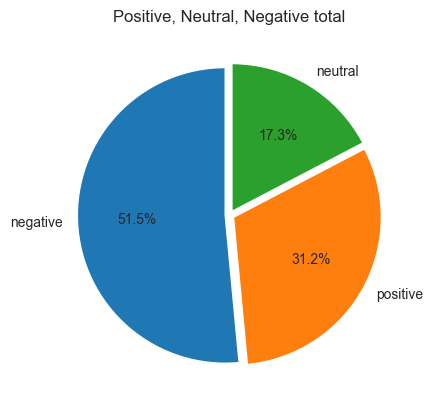

In [18]:
import matplotlib.pyplot as plt

data = clean_df["polarity"].value_counts()
print(data)

plt.pie(data.values, labels=list(data.keys()) ,explode=[0.03, 0.03, 0.03], autopct="%1.1f%%", startangle=90)
plt.title("Positive, Neutral, Negative total")
plt.show()

__Get polarity text__

In [19]:
def get_polarity_text(polarity_name):
    indices = clean_df[clean_df["polarity"] == polarity_name].index
    text = clean_df.loc[indices, "final_text"].tolist()

    return ' '.join(text)

positive_text = get_polarity_text("positive")
neutral_text = get_polarity_text("neutral")
negative_text = get_polarity_text("negative")

__Visualization to WorldCloud__

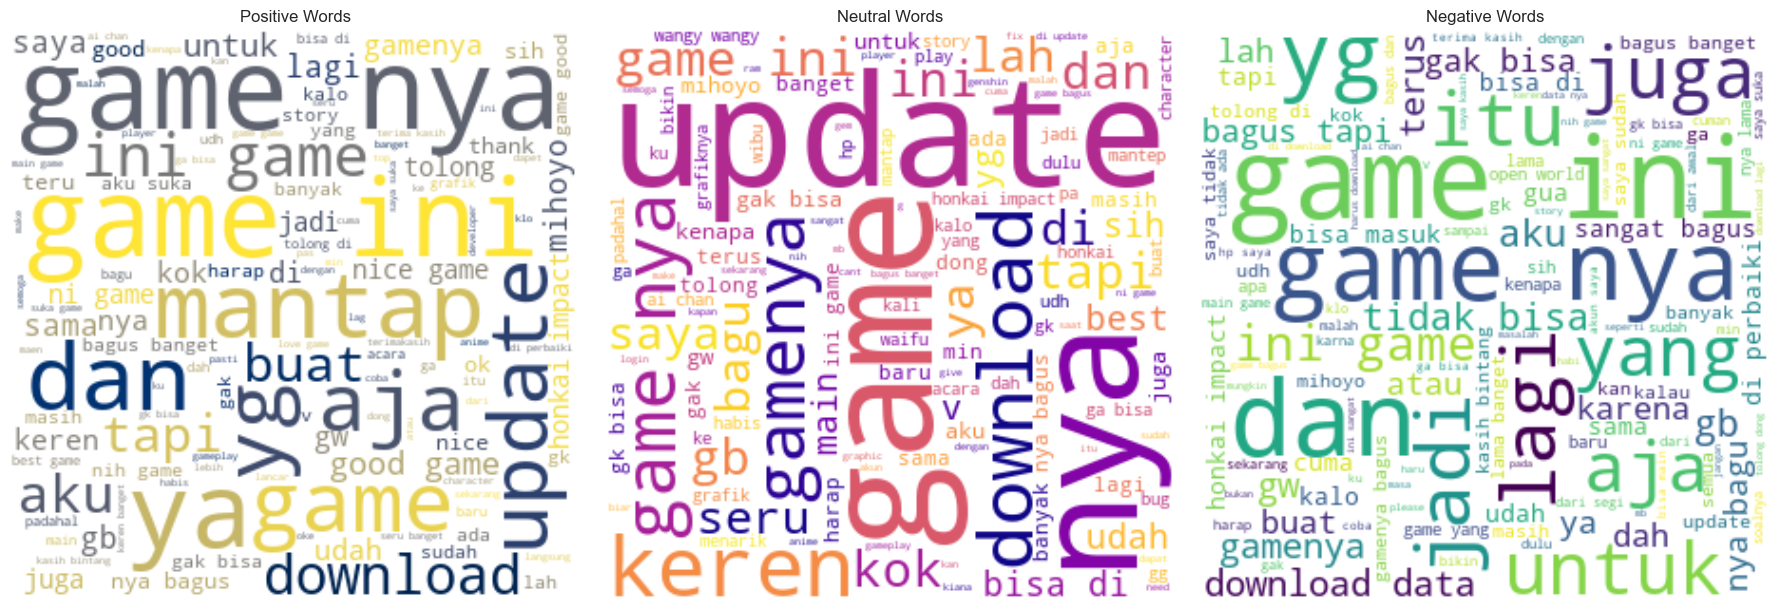

In [20]:
from wordcloud import WordCloud

wc_positive = WordCloud(width=300, height=300, background_color="white", colormap="cividis", max_words=120).generate(positive_text)
wc_neutral = WordCloud(width=300, height=300, background_color="white", colormap="plasma", max_words=120).generate(neutral_text)
wc_negative = WordCloud(width=300, height=300, background_color="white", colormap="viridis", max_words=120).generate(negative_text)

_, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(wc_positive, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Positive Words")

axes[1].imshow(wc_neutral, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Neutral Words")

axes[2].imshow(wc_negative, interpolation="bilinear")
axes[2].axis("off")
axes[2].set_title("Negative Words")

plt.tight_layout()
plt.show()

### Encoding labels
+ __Positive__  : 0
+ __Negative__  : 1
+ __Neutral__   : 2

In [21]:
clean_df["polarity"] = clean_df["polarity"].apply(
    lambda x: 0 if x == "positive" else 1 if x == "negative" else 2
)

### Modeling

In [22]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import BernoulliNB
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imPipeline
from sklearn.feature_extraction.text import CountVectorizer

In [23]:
def data_labeling(models, sampling_method, params_grid=None):
    results = []
    for model_name, model in models.items():
        for sampling_name, sampling in sampling_method.items():
            # Merge
            steps = [("tfidf", TfidfVectorizer(max_features=200, min_df=17, max_df=0.8))]

            if sampling:
                steps.append(("sampler", sampling))

            steps.append(("classifier", model))

            # Make pipeline
            pipeline = imPipeline(steps)
            pipeline.fit(X_train, y_train)

            # Setup grid search if used
            if params_grid:
                param_grid = params_grid.get(model_name, {})
                grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)
                grid_search.fit(X_train, y_train)

                # Predict model
                y_pred_train = grid_search.predict(X_train)
                y_pred_test = grid_search.predict(X_test)
            else:
                y_pred_train = pipeline.predict(X_train)
                y_pred_test = pipeline.predict(X_test)

            # Evaluation
            accuracy_train = accuracy_score(y_train, y_pred_train)
            accuracy_test = accuracy_score(y_test, y_pred_test)

            results.append({
                "Model": model_name,
                "Sampler": sampling_name,
                "Accuracy train": accuracy_train,
                "Accuracy test": accuracy_test,
                **({"Best param": grid_search.best_params_ if params_grid else {}})
            })
    return results

def highlight_best_3(df):
    top_3_indices = df.nlargest(3, "Accuracy test").index

    def highlight(row):
        return ["background-color: lightgreen" if i in top_3_indices else '' for i in row.index]
    return df.style.apply(highlight, axis=1)


### Data label
+ Data label with keywords sentiment
+ Using Pipeline with some machine learning models
+ Using TF-IFD
+ Using sampling method like smote, random user sampling, dan without sampling
+ Without gridsearch

In [24]:
# Split data

X = clean_df["final_text"]
y = clean_df["polarity"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Sampling
smote = SMOTE(random_state=42)
under_sampler = RandomUnderSampler(random_state=42)

# Make list models
models = {
    'SVM': SVC(kernel='linear', C=1.0, decision_function_shape='ovr', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, solver='liblinear', multi_class='ovr', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, criterion='entropy', random_state=42),
}

results = []

sampling_methods = {
    "SMOTE": smote,
    "None": None,
    "Random Under Samping": under_sampler
}

results_df = pd.DataFrame(data_labeling(models, sampling_methods))

styled_results_df = highlight_best_3(results_df)
display(styled_results_df)

D:\Document\Learn Machine Learning\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
D:\Document\Learn Machine Learning\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
D:\Document\Learn Machine Learning\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


,Model,Sampler,Accuracy train,Accuracy test,Best param
0,SVM,SMOTE,0.798595,0.800161,{}
1,SVM,None,0.805444,0.807716,{}
2,SVM,Random Under Samping,0.794087,0.794923,{}
3,Random Forest,SMOTE,0.678124,0.680298,{}
4,Random Forest,None,0.644028,0.642929,{}
5,Random Forest,Random Under Samping,0.672509,0.676773,{}
6,Logistic Regression,SMOTE,0.797210,0.804089,{}
7,Logistic Regression,None,0.803933,0.805197,{}
8,Logistic Regression,Random Under Samping,0.788749,0.794722,{}
9,Decision Tree,SMOTE,0.619853,0.616438,{}
